# Lojistik Regresyon Algoritması

**Veri Seti:** bank.csv — Banka Pazarlama Kampanyası (Bank Marketing, UCI)

---

## 1. Konu Anlatımı — Lojistik Regresyon Nedir?

Lojistik regresyon, **sınıflandırma** problemleri için kullanılan bir makine öğrenmesi algoritmasıdır. İsminde "regresyon" geçse de aslında bir sınıflandırma yöntemidir.

### 1.1. Temel Mantık
Lineer regresyonda çıktı sürekli bir sayı iken, sınıflandırmada çıktının 0 ile 1 arasında bir **olasılık** olması istenir. Bu yüzden lineer kombinasyonun (z = β₀ + β₁x₁ + ... + βₙxₙ) çıktısı **sigmoid (lojistik) fonksiyonundan** geçirilir:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Bu fonksiyon herhangi bir gerçek sayıyı 0 ile 1 arasına sıkıştırır, böylece çıktı bir olasılık gibi yorumlanabilir.

### 1.2. Karar Sınırı
Model σ(z) ≥ 0.5 ise sınıf 1, aksi halde sınıf 0 tahmini yapar. Bu eşik değeri probleme göre değiştirilebilir (örneğin dengesiz veri setlerinde recall'u artırmak için düşürülebilir).

### 1.3. Kayıp Fonksiyonu
Model, **çapraz entropi (cross-entropy / log-loss)** kayıp fonksiyonunu minimize edecek şekilde β katsayılarını öğrenir:

$$J(\beta) = -\frac{1}{m}\sum_{i=1}^{m}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

### 1.4. Bu Çalışmada Ele Alınan Problem
Bu defterde **Bank Marketing** veri setini kullanacağız. Veri seti, bir Portekiz bankasının telefonla yaptığı pazarlama kampanyasına ait müşteri bilgilerini içerir. Amaç, bir müşterinin **vadeli mevduat ürününe abone olup olmayacağını** (`y`: 0 = hayır, 1 = evet) tahmin etmektir.

Bu veri setinin önemli bir özelliği **sınıf dengesizliğidir**: abone olan müşteri sayısı, olmayanlara göre çok azdır. Bu durum, model değerlendirmesinde sadece "doğruluk" (accuracy) metriğine güvenmemizi engeller; precision, recall, F1 ve ROC-AUC gibi metriklere de bakmamız gerekir.

## 2. Gerekli Kütüphaneler

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

## 3. Veriyi Yükleme ve Keşfetme

In [2]:
df = pd.read_csv("bank.csv", sep=";")

print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
print(f"\nSütun isimleri:\n{', '.join(df.columns.tolist())}")
print(f"\nSınıf dağılımı (target):")
print(df['y'].value_counts())
print(f"\nSınıf oranı (%):")
print((df['y'].value_counts(normalize=True) * 100).round(2))
print(f"\nİlk 5 satır:")
display(df.head())
print(f"\nEksik değer sayısı: {df.isnull().sum().sum()}")

Veri seti boyutu: 45211 satır, 17 sütun

Sütun isimleri:
age, job, marital, education, default, balance, housing, loan, contact, day, month, duration, campaign, pdays, previous, poutcome, y

Sınıf dağılımı (target):
y
no     39922
yes     5289
Name: count, dtype: int64

Sınıf oranı (%):
y
no     88.3
yes    11.7
Name: proportion, dtype: float64

İlk 5 satır:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Eksik değer sayısı: 0


**Not — Sınıf Dengesizliği:** `y` sütununun dağılımına bakıldığında pozitif sınıfın (abone olanlar) çok daha az olduğu görülür. Bu yüzden ilerleyen adımlarda hem `class_weight='balanced'` parametresini deneyeceğiz hem de değerlendirmede accuracy'nin yanında precision/recall/F1/AUC metriklerini kullanacağız.

## 4. Kategorik Değişkenlerin Sayısallaştırılması

Veri setindeki `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `month`, `day_of_week`, `poutcome` gibi sütunlar kategoriktir. Lojistik regresyon sayısal girdiler beklediği için bunları **one-hot encoding** ile sayısal sütunlara dönüştürüyoruz. Ayrıca `duration` (görüşme süresi) sütunu, görüşme bitene kadar bilinemeyeceği ve hedefle çok güçlü ilişkili olduğu (veri sızıntısı - data leakage) için modele dahil edilmiyor.

In [3]:
df_model = df.drop(columns=["duration"]).copy()
df_model["y"] = df_model["y"].map({"no": 0, "yes": 1})

categorical_cols = df_model.select_dtypes(include="object").columns.tolist()
categorical_cols = [c for c in categorical_cols if c != "y"]

print("Kategorik sütunlar:", categorical_cols)

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f"\nEncoding sonrası boyut: {df_encoded.shape}")

Kategorik sütunlar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Encoding sonrası boyut: (45211, 42)


/tmp/ipykernel_542/1716049589.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include="object").columns.tolist()


## 5. Özellik ve Hedef Ayırma

In [4]:
X = df_encoded.drop("y", axis=1)
y = df_encoded["y"]

print(f"Özellik matrisi (X): {X.shape}")
print(f"Hedef vektör (y):   {y.shape}")

Özellik matrisi (X): (45211, 41)
Hedef vektör (y):   (45211,)


## 6. Eğitim/Test Ayrımı

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim seti: {X_train.shape[0]} örnek")
print(f"Test seti:   {X_test.shape[0]} örnek")
print(f"\nEğitim seti sınıf dağılımı:\n{y_train.value_counts()}")
print(f"\nTest seti sınıf dağılımı:\n{y_test.value_counts()}")

Eğitim seti: 36168 örnek
Test seti:   9043 örnek

Eğitim seti sınıf dağılımı:
y
0    31937
1     4231
Name: count, dtype: int64

Test seti sınıf dağılımı:
y
0    7985
1    1058
Name: count, dtype: int64


## 7. Özellik Ölçeklendirme (Standardizasyon)

Lojistik regresyon gradyan inişi kullandığı için özelliklerin aynı ölçekte olması önemlidir.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Özellikler standardize edildi (mean=0, std=1)")
print(f"\nEğitim seti ilk satır (ölçeklenmiş, ilk 5 değer):")
print(np.round(X_train_scaled[0][:5], 3))

Özellikler standardize edildi (mean=0, std=1)

Eğitim seti ilk satır (ölçeklenmiş, ilk 5 değer):
[-0.46  -0.164  1.582 -0.246 -0.411]


## 8. Lojistik Regresyon Modeli Eğitimi

Scikit-learn'in `LogisticRegression` sınıfını kullanıyoruz.
- `penalty='l2'`: L2 regularization (overfitting'i önler)
- `C=1.0`: Regularizasyon şiddetinin tersi
- `solver='lbfgs'`: Optimizasyon algoritması
- `class_weight='balanced'`: Sınıf dengesizliğini telafi etmek için ağırlıklandırma
- `max_iter=1000`: Maksimum iterasyon sayısı

In [7]:
model = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', class_weight='balanced', max_iter=1000, random_state=42
)
model.fit(X_train_scaled, y_train)
print("Model eğitimi tamamlandı.")

Model eğitimi tamamlandı.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [8]:
print(f"Kesişim (bias - β₀): {model.intercept_[0]:.4f}")
print(f"\nEn etkili 10 katsayı (mutlak değere göre):")
coef_df = pd.DataFrame({
    'Özellik': X.columns,
    'Katsayı': model.coef_[0],
    '|Katsayı|': np.abs(model.coef_[0])
}).sort_values('|Katsayı|', ascending=False)
display(coef_df.head(10))

Kesişim (bias - β₀): -0.3552

En etkili 10 katsayı (mutlak değere göre):


,Özellik,Katsayı,|Katsayı|
26,contact_unknown,-0.542908,0.542908
39,poutcome_success,0.422625,0.422625
27,month_aug,-0.272236,0.272236
35,month_nov,-0.235682,0.235682
23,housing_yes,-0.232281,0.232281
31,month_jul,-0.231853,0.231853
3,campaign,-0.222175,0.222175
34,month_may,-0.217835,0.217835
30,month_jan,-0.191340,0.191340
20,education_tertiary,0.142671,0.142671


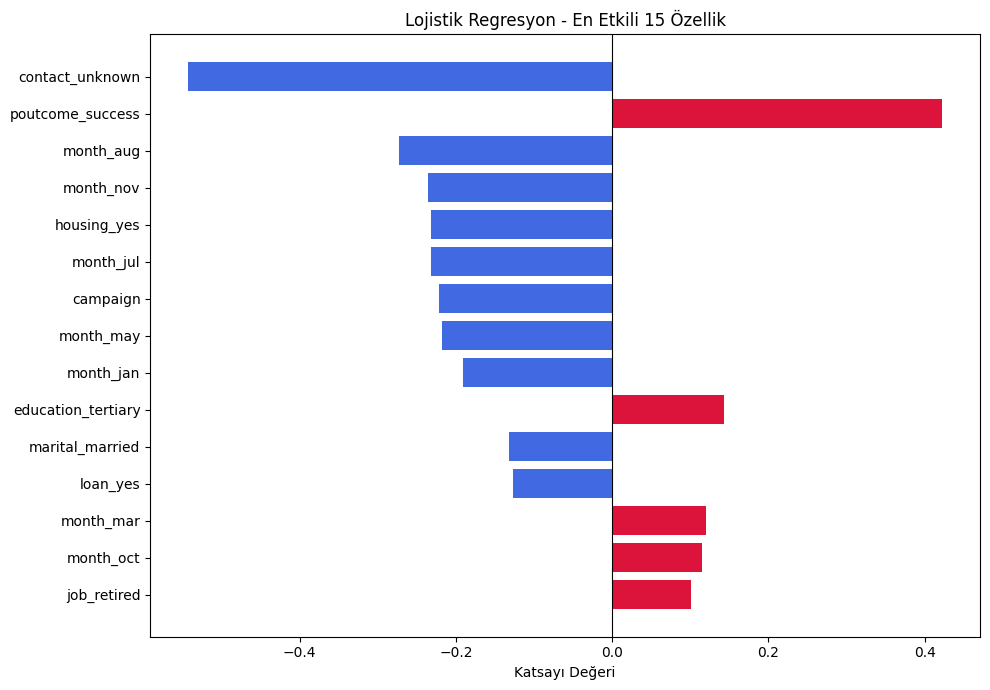

In [9]:
top_n = 15
top_coef = coef_df.head(top_n)
plt.figure(figsize=(10, 7))
colors = ['crimson' if c > 0 else 'royalblue' for c in top_coef['Katsayı']]
plt.barh(top_coef['Özellik'], top_coef['Katsayı'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Katsayı Değeri')
plt.title(f'Lojistik Regresyon - En Etkili {top_n} Özellik')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Model Değerlendirme

In [10]:
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"Doğruluk (Accuracy):     {accuracy:.4f}")
print(f"Hassasiyet (Precision):  {precision:.4f}")
print(f"Duyarlılık (Recall):     {recall:.4f}")
print(f"F1-Skoru:                {f1:.4f}")
print(f"ROC-AUC:                 {auc_roc:.4f}")

Doğruluk (Accuracy):     0.7557


Hassasiyet (Precision):  0.2669
Duyarlılık (Recall):     0.6229
F1-Skoru:                0.3737
ROC-AUC:                 0.7722


In [11]:
cm = confusion_matrix(y_test, y_pred)

print("=== KARIŞIKLIK MATRİSİ (Confusion Matrix) ===")
print(f"               Tahmin: 0    Tahmin: 1")
print(f"  Gerçek: 0     {cm[0,0]:5d} (TN)     {cm[0,1]:5d} (FP)")
print(f"  Gerçek: 1     {cm[1,0]:5d} (FN)     {cm[1,1]:5d} (TP)")

=== KARIŞIKLIK MATRİSİ (Confusion Matrix) ===
               Tahmin: 0    Tahmin: 1
  Gerçek: 0      6175 (TN)      1810 (FP)
  Gerçek: 1       399 (FN)       659 (TP)


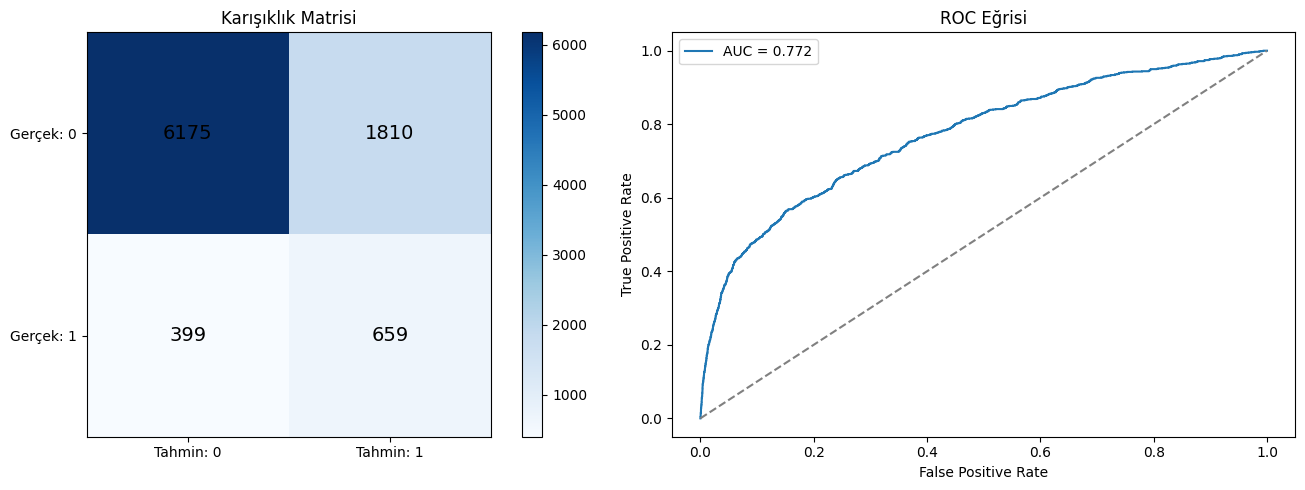

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

im = ax[0].imshow(cm, cmap='Blues')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Tahmin: 0', 'Tahmin: 1'])
ax[0].set_yticklabels(['Gerçek: 0', 'Gerçek: 1'])
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14)
ax[0].set_title('Karışıklık Matrisi')
plt.colorbar(im, ax=ax[0])

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax[1].plot(fpr, tpr, label=f"AUC = {auc_roc:.3f}")
ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Eğrisi')
ax[1].legend()

plt.tight_layout()
plt.show()

## 10. Örnek Tahmin

In [13]:
sample = X_test.iloc[0:1]
sample_scaled = scaler.transform(sample)
sample_proba = model.predict_proba(sample_scaled)[0, 1]
sample_pred = model.predict(sample_scaled)[0]

print("Örnek müşteri verisi (ilk 8 sütun):")
display(sample.iloc[:, :8])
print(f"\nAbone olma olasılığı: {sample_proba:.4f} ({sample_proba*100:.1f}%)")
print(f"Tahmin edilen sınıf: {sample_pred} ({'Abone olur' if sample_pred == 1 else 'Abone olmaz'})")
print(f"Gerçek sınıf: {y_test.iloc[0]}")

Örnek müşteri verisi (ilk 8 sütun):


,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur
1392,40,640,8,2,-1,0,True,False



Abone olma olasılığı: 0.1068 (10.7%)
Tahmin edilen sınıf: 0 (Abone olmaz)
Gerçek sınıf: 0


## 11. Sonuç

### Önemli Kavramların Özeti
1. **Sigmoid fonksiyonu**: Lineer çıktıyı 0-1 arası olasılığa dönüştürür.
2. **Karar sınırı**: σ(z) = 0.5 eşiği ile sınıflandırma yapılır.
3. **Cross-Entropy loss**: Model, tahmin edilen olasılıklarla gerçek etiketler arasındaki farkı minimize edecek şekilde eğitilir.
4. **Sınıf dengesizliği**: Bank Marketing veri setinde pozitif sınıf az olduğundan `class_weight='balanced'` kullanıldı ve değerlendirmede accuracy tek başına yeterli kabul edilmedi.
5. **One-hot encoding**: Kategorik değişkenler modele verilmeden önce sayısal forma dönüştürüldü.

Aşağıda genel sonuç tablosu özetlenmiştir.

In [14]:
print("=== SONUÇ TABLOSU ===")
print(f"  Doğruluk (Accuracy):     {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"  Hassasiyet (Precision):  {precision:.4f}  ({(precision*100):.2f}%)")
print(f"  Duyarlılık (Recall):     {recall:.4f}  ({(recall*100):.2f}%)")
print(f"  F1-Skoru:                {f1:.4f}")
print(f"  ROC-AUC:                 {auc_roc:.4f}")

=== SONUÇ TABLOSU ===
  Doğruluk (Accuracy):     0.7557  (75.57%)
  Hassasiyet (Precision):  0.2669  (26.69%)
  Duyarlılık (Recall):     0.6229  (62.29%)
  F1-Skoru:                0.3737
  ROC-AUC:                 0.7722
